In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv')
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [2]:
df = df.dropna(subset=['Customer ID'])
df = df[df['Quantity'] > 0]

df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      805620 non-null  object 
 1   StockCode    805620 non-null  object 
 2   Description  805620 non-null  object 
 3   Quantity     805620 non-null  int64  
 4   InvoiceDate  805620 non-null  object 
 5   Price        805620 non-null  float64
 6   Customer ID  805620 non-null  float64
 7   Country      805620 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 55.3+ MB


In [3]:
df['totalprice']= df['Price'] * df['Quantity']

In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  object        
 1   StockCode    805620 non-null  object        
 2   Description  805620 non-null  object        
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[ns]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  float64       
 7   Country      805620 non-null  object        
 8   totalprice   805620 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 61.5+ MB


In [5]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [6]:
rfm = df.groupby('Customer ID').agg(
    Frequency=('Invoice', 'nunique'),
    Monetary=('totalprice', 'sum'),
    Recency=('InvoiceDate', 'max')
)

In [7]:
rfm['Recency'] = pd.to_datetime(rfm['Recency'])
rfm['Recency'] = (reference_date - rfm['Recency']).dt.days
rfm.head()

,Frequency,Monetary,Recency
Customer ID,,,
12346.0,12,77556.46,326
12347.0,8,5633.32,2
12348.0,5,2019.40,75
12349.0,4,4428.69,19
12350.0,1,334.40,310


In [8]:
print(reference_date)
print(rfm['Recency'].head())

2011-12-10 12:50:00
Customer ID
12346.0    326
12347.0      2
12348.0     75
12349.0     19
12350.0    310
Name: Recency, dtype: int64


In [9]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Frequency=('Invoice', 'nunique'),
    Monetary=('totalprice', 'sum'),
    Recency=('InvoiceDate', 'max')
)

rfm['Recency'] = (reference_date - rfm['Recency']).dt.days
rfm.head()

,Frequency,Monetary,Recency
Customer ID,,,
12346.0,12,77556.46,326
12347.0,8,5633.32,2
12348.0,5,2019.40,75
12349.0,4,4428.69,19
12350.0,1,334.40,310


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [11]:
from sklearn.cluster import KMeans

inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

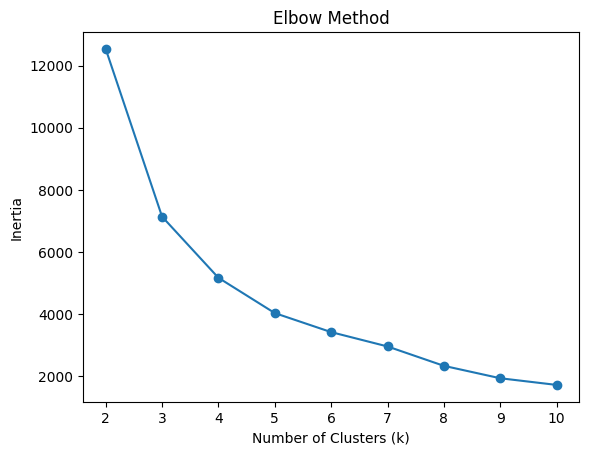

In [12]:
import matplotlib.pyplot as plt

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [13]:
km = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = km.fit_predict(rfm_scaled)
rfm.head()

,Frequency,Monetary,Recency,Cluster
Customer ID,,,,
12346.0,12,77556.46,326,0
12347.0,8,5633.32,2,0
12348.0,5,2019.40,75,0
12349.0,4,4428.69,19,0
12350.0,1,334.40,310,1


In [14]:
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)

,Recency,Frequency,Monetary
Cluster,,,
0,66.9,7.3,3009.1
1,463.0,2.2,765.8
2,25.9,103.7,83086.1
3,3.5,212.8,436835.8


In [15]:
cluster_labels = {3: 'Champions', 2: 'Loyal', 0: 'At-Risk', 1: 'Lost'}
rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
rfm.head(10)

,Frequency,Monetary,Recency,Cluster,Segment
Customer ID,,,,,
12346.0,12,77556.46,326,0,At-Risk
12347.0,8,5633.32,2,0,At-Risk
12348.0,5,2019.40,75,0,At-Risk
12349.0,4,4428.69,19,0,At-Risk
12350.0,1,334.40,310,1,Lost
12351.0,1,300.93,375,1,Lost
12352.0,10,2849.84,36,0,At-Risk
12353.0,2,406.76,204,0,At-Risk
12354.0,1,1079.40,232,0,At-Risk


In [16]:
rfm['Segment'].value_counts()

Segment
At-Risk      3840
Lost         2002
Loyal          35
Champions       4
Name: count, dtype: int64

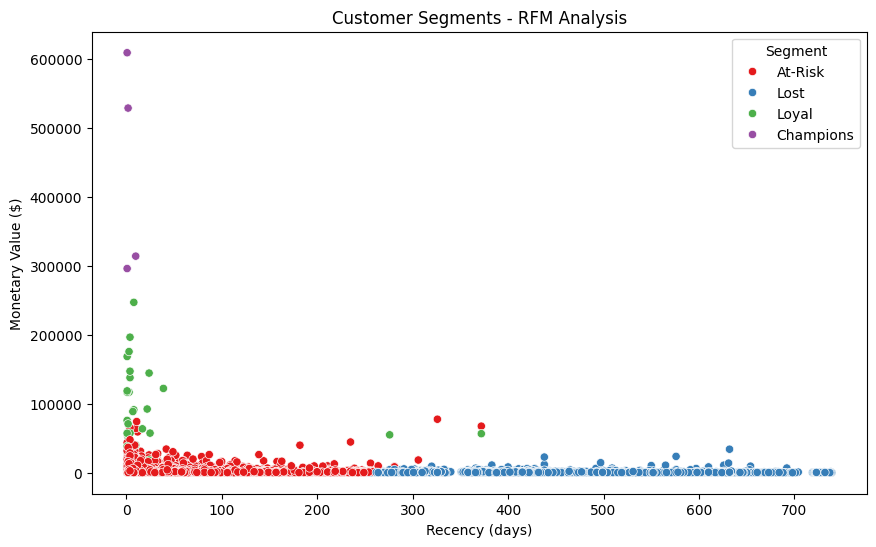

In [17]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment', palette='Set1')
plt.title('Customer Segments - RFM Analysis')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary Value ($)')
plt.legend(title='Segment')
plt.show()

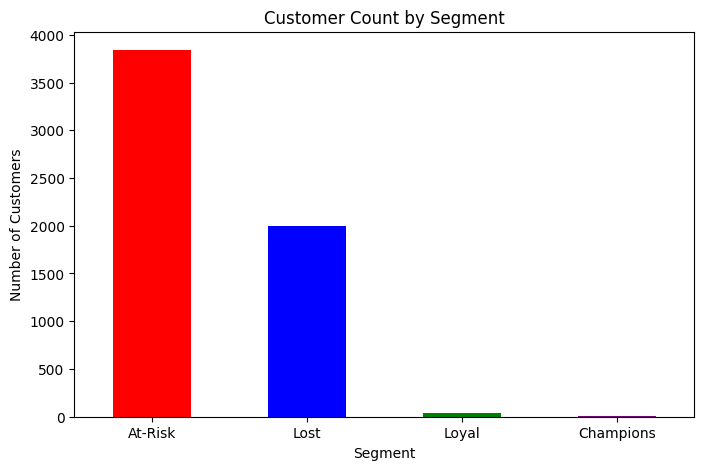

In [18]:
plt.figure(figsize=(8, 5))
rfm['Segment'].value_counts().plot(kind='bar', color=['red', 'blue', 'green', 'purple'])
plt.title('Customer Count by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [19]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.591


## Business Insights & Recommendations

**Dataset:** 5,881 unique customers | UCI Online Retail II

**Segmentation Results:**
| Segment | Customers | Avg Recency | Avg Frequency | Avg Monetary |
|---|---|---|---|---|
| Champions | 4 | 3.5 days | 212.8 orders | $436,835 |
| Loyal | 35 | 25.9 days | 103.7 orders | $83,086 |
| At-Risk | 3,840 | 66.9 days | 7.3 orders | $3,009 |
| Lost | 2,002 | 463 days | 2.2 orders | $765 |

**Key Findings:**
- 65% of customers are At-Risk — immediate re-engagement campaigns needed
- Champions and Loyal customers (39 total) drive disproportionate revenue — protect them with loyalty rewards
- Lost customers (2,002) have not purchased in 463 days on average — consider win-back email campaigns with discounts
- Silhouette Score of 0.591 confirms well-separated, meaningful clusters